In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time as time_package
import scipy.stats as stats
import matplotlib.pyplot as plt
       
from scipy.linalg import inv
from scipy.special import logsumexp
from multiprocessing import pool

from research_code import *
from scipy.fft import fft, fftfreq

In [2]:
import matplotlib as mpl

MM_TO_INCH = 1/25.4

TEXTWIDTH_MM = 164.6
FIG_W = TEXTWIDTH_MM * MM_TO_INCH
FIG_H = 25 * MM_TO_INCH
plt.style.use('seaborn-v0_8-whitegrid')

mpl.rcParams.update({
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "axes.grid.which": "major",
    "axes.axisbelow": True,


    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,

    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",

    'lines.linewidth': 0.6,

    "font.family": "serif", 
    "font.serif": ["Times New Roman"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7.5,

    "figure.figsize": (FIG_W, FIG_H),

    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "mathtext.fontset": "stix",
})

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set1.colors)
plt.rcParams['axes.unicode_minus'] = False

mpl.rcParams['figure.dpi'] = 150

np.random.seed(1)

data_dir = os.path.join(project_root,'data')
fig_dir = os.path.join(data_dir,'figures')

labels = ['UKF-UI','HKF-ndm','HKFS-ndm','HKF','HKFS',]
colors = ['#181','#a55','#a11','#55a','#11a']
highlight_color = '#fdf2d0a0'
example_name = 'benchmark'

nsbb = NSBB()
system = nsbb.system

In [3]:
time = Time(0,31.18,0.02)

eq = []
with open(os.path.join(data_dir,'ELCENTRO/elCentro.dat'),'rb') as f:
    for data in f:
        try:
            eq +=list(map(float, data.split()))
        except:
            pass
eq = np.array(eq)*386.22
eq = np.insert(eq,0,0)

point_num = 1559
dt = 0.02
time_point = np.linspace(0,point_num*dt,point_num+1)

force_value = eq
force = Force.assign_by_value(time_point = time_point, value = force_value)
force.interp(time)

intensity = np.cumsum(eq**2)/np.sum(eq**2)
idx_05 = np.where(intensity >= 0.05)[0][0]
idx_95 = np.where(intensity >= 0.95)[0][0]
print(f't_05: {time_point[idx_05]}, t_95: {time_point[idx_95]}, duration: {time_point[idx_95]-time_point[idx_05]}')

t_05: 1.68, t_95: 25.52, duration: 23.84


In [4]:
time = Time(0, 31.18, 0.001)
force.interp(time)

response_rom = compute_response(
    system = system,
    force = force,
    time = time,
    ctype = 'Newmark',
    )
time,force,response_rom = slice_data(time,force,response_rom,0.02)

In [5]:
def load_data(file_path):
    data = []
    with open(os.path.join(data_dir,file_path), 'r', encoding='utf-8') as file:
        for line in file:
                values = line.strip().split()
                row = [float(value) for value in values[2:]]
                data.append(row)
    return data

real_disp = np.array(load_data("disp_n.out")).T
real_vel = np.array(load_data("vel_n.out")).T
real_acc = np.array(load_data("acc_n.out")).T


4.86223622126041


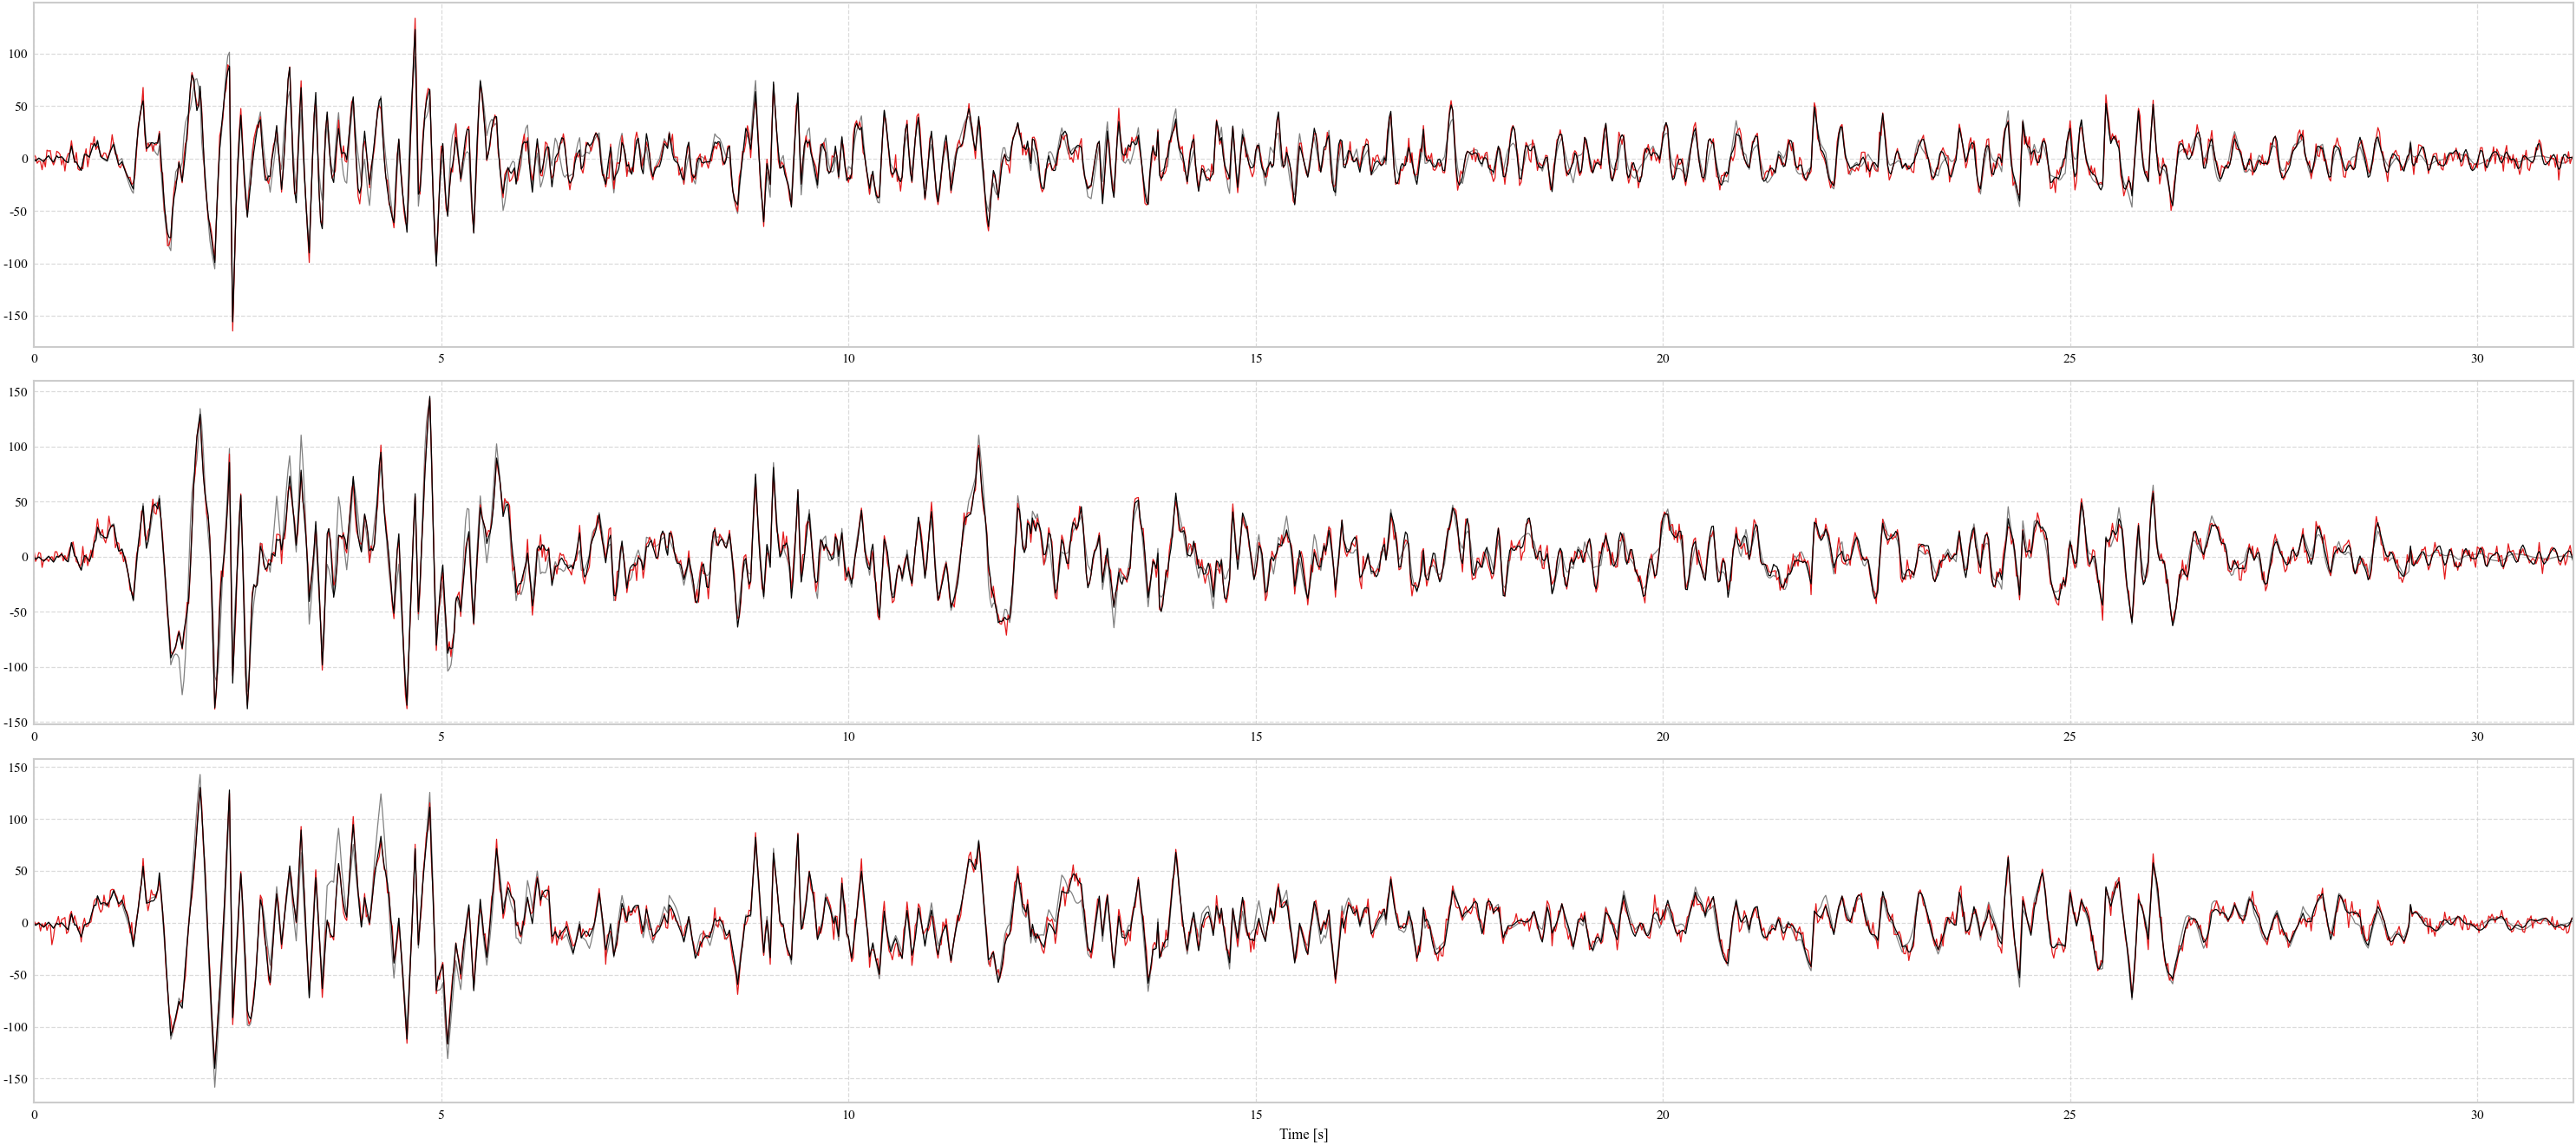

In [6]:
SNR_dB = 15
std_noise = (np.var(real_acc) / (10**(SNR_dB/10)))**0.5
print(std_noise)
m_number = 50
measurement_set = np.zeros((m_number,system.dim,time.length))
measurement_dm_set = np.zeros((m_number,(system.dim+9+system.force_dim),time.length))
for ii in range(m_number):
    measurement = add_noise(real_acc,std_noise)
    measurement_dm = np.vstack((measurement,np.zeros((9,time.length)),np.zeros((system.force_dim,time.length))))
    measurement_set[ii] = measurement
    measurement_dm_set[ii] = measurement_dm


plt.figure(figsize=(20,9))
re = [0,4,8]
for ii in range(3):
    plt.subplot(3,1,ii+1)
    f = re[ii]
    plt.plot(time.value, response_rom.acc[f,:],color='grey')
    plt.plot(time.value, measurement[f,:])
    plt.plot(time.value, real_acc[f,:],color='k')
    plt.xlim([0,31.18])
plt.xlabel('Time [s]')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir,'measurement_'+example_name+'.pdf'))

In [7]:
def UKFUI(system, time, initial_state, initial_cov, model_cov, measurement_cov, measurement, alpha, p=False):
    state_dim = system.dim * 2 + system.element_dim
    force_dim = system.force_dim

    est_state = np.zeros((state_dim, time.length))
    est_cov = np.zeros((state_dim, state_dim, time.length))
    est_force = np.zeros((force_dim, time.length))

    state = initial_state
    cov = initial_cov
    force = np.zeros(force_dim)
    acc = compute_acc(system, state, force)

    beta = 2.0
    kappa = 0.0

    n = system.dim * 2 + 9
    lam = alpha**2 * (n) - n
    c = n + lam

    Wm = np.full(2*n + 1, 1.0/(2*c))
    Wc = np.full(2*n + 1, 1.0/(2*c))
    Wm[0] = lam / c
    Wc[0] = lam / c + (1 - alpha**2 + beta)
    u_index = np.array(range(system.dim))
    for ii in range(9):
        u_index = np.append(u_index, system.dim + NSBB().bw_index[ii])
        u_index = np.append(u_index, system.dim + system.element_dim + ii)
    u_index.sort()
    u_index = np.array(u_index)

    for ii in range(1,time.length):
        cov_u = cov[np.ix_(u_index, u_index)]
        sigma_points = np.zeros((state_dim, 2*n + 1))
        sigma_points[:,0] = state
        L = np.linalg.cholesky(cov_u)
        for j in range(n):
            sigma_points[u_index.flatten(), j+1] = state[u_index] + np.sqrt(c) * L[:, j]
            sigma_points[u_index.flatten(), j+1+n] = state[u_index] - np.sqrt(c) * L[:, j]
        state_pred_points = compute_response_step(system, time, sigma_points, force, acc)
        state_pred = np.sum(Wm * state_pred_points, axis=1)
        diff = state_pred_points - state_pred[:, None]
        cov_pred = diff @ np.diag(Wc) @ diff.T + model_cov
        
        Cc1 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag(system.alpha*system.element_stiff)@system.comp_mat)
        Cc2 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag((1-system.alpha)*system.element_stiff))
        Cc3 = np.atleast_2d(-inv(system.mass)@system.damping)
        Cc4 = np.atleast_2d(inv(system.mass)@system.force_influence)
        Cc = np.hstack((Cc1, Cc2, Cc3))
        force = inv(Cc4.T@Cc4)@(Cc4.T)@(measurement[:,ii] - Cc @ state_pred)

        meas_pred_points = compute_acc(system, state_pred_points, force[:,None])
        meas_pred = np.sum(Wm * meas_pred_points, axis=1)
        meas_diff = meas_pred_points - meas_pred[:, None]
        cov_meas = meas_diff @ np.diag(Wc) @ meas_diff.T + measurement_cov

        cross_diff = state_pred_points - state_pred[:, None]
        cross_cov = cross_diff @ np.diag(Wc) @ meas_diff.T
        K = cross_cov @ np.linalg.inv(cov_meas)


        state = state_pred + K @ (measurement[:,ii] - meas_pred)
        cov = cov_pred - K @ cov_meas @ K.T
        
        acc = compute_acc(system, state, force)

        est_state[:,ii] = state
        est_cov[:,:,ii] = cov
        est_force[:,ii] = force
        if p and ii % 10 == 0:
            print(f"{ii}/{time.length}", end='\r')
    return est_state, est_cov, est_force

def compute_response_step(system, time, state_list, force, acc):
    state_post = np.zeros(state_list.shape)
    acc_post = np.zeros((system.dim, state_list.shape[1]))

    GAMMA = 1/2
    BETA  = 1/4
    dt    = time.interval

    A1 = 1/(BETA*dt**2) * system.mass + (GAMMA/(BETA*dt)) * system.damping
    A2 = 1/(BETA*dt)    * system.mass + (GAMMA/BETA - 1) * system.damping
    A3 = (1/(2*BETA) - 1) * system.mass + system.damping*dt*(GAMMA/(2*BETA) - 1)

    MAX_ITER = 200
    for ii in range(state_list.shape[1]):
        state = state_list[:, ii]

        disp0 = state[0:system.dim].copy()
        aux0  = state[system.dim:system.dim+system.element_dim].copy()
        vel0  = state[system.dim+system.element_dim : system.dim*2+system.element_dim].copy()

        disp = disp0.copy()
        aux  = aux0.copy()

        force_hat = (system.force_influence @ force + A1 @ disp0 + A2 @ vel0 + A3 @ acc)

        for jj in range(MAX_ITER):
            
            element_disp = system.comp_mat @ disp
            resisting_force = (system.alpha * system.element_stiff * element_disp + (1 - system.alpha) * system.element_stiff * aux)
            
            residual_force = force_hat - system.comp_mat.T @ resisting_force - A1 @ disp

            if (np.all(residual_force**2 < 1e-18) or np.all(residual_force**2 / np.maximum(np.max(np.abs(force_hat)), 1e-10)**2 < 1e-18)):
                break

            if system.model == 'BoucWen':
                vel_e = system.comp_mat @ vel0
                g = (system.A - np.abs(aux)**system.n * (system.gamma + system.beta * np.sign(aux * vel_e)))
                k_t_elem = (system.alpha * system.element_stiff + (1 - system.alpha) * system.element_stiff * g)
                K_tangent = system.comp_mat.T @ np.diag(k_t_elem) @ system.comp_mat
                tangent_stiff_hat = K_tangent + A1
            else:
                tangent_stiff_hat = system.stiff + A1

            delta_disp = np.linalg.solve(tangent_stiff_hat, residual_force)

            disp_new = disp + delta_disp

            if system.model == 'BoucWen':
                element_disp_new = system.comp_mat @ disp_new
                delta_element_disp = element_disp_new - element_disp
                aux = aux + delta_element_disp * g

            disp = disp_new

        if jj == MAX_ITER - 1 and np.any(np.abs(residual_force) >= 1e-12):
            print(residual_force, force_hat)
            print('Newton-Raphson did not converge')

        vel = (GAMMA/(BETA*dt))*(disp - disp0) + (1 - GAMMA/BETA)*vel0 + dt*(1 - GAMMA/(2*BETA))*acc

        state_post[:, ii] = np.concatenate((disp, aux, vel))

    return state_post

def compute_acc(system, state, force):
    Cc1 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag(system.alpha*system.element_stiff)@system.comp_mat)
    Cc2 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag((1-system.alpha)*system.element_stiff))
    Cc3 = np.atleast_2d(-inv(system.mass)@system.damping)
    Cc4 = np.atleast_2d(inv(system.mass)@system.force_influence)
    Cc = np.hstack((Cc1, Cc2, Cc3))
    return Cc@state + Cc4@force

In [8]:
UKFUI_results = []
time_UKF = np.zeros(m_number)
for ii in range(m_number):
    measurement = measurement_set[ii]
    initial_state = np.zeros(system.dim*2+system.element_dim)
    initial_cov = np.eye(system.dim*2+system.element_dim)*10**-10.0
    model_cov = np.diag([10**-6.0]*(system.dim+system.element_dim)+[10**-3.0]*(system.dim))
    measurement_cov = np.diag([std_noise**2]*system.dim)
    scale = 1
    start_time = time_package.perf_counter()
    est_state, est_cov, est_force = UKFUI(system, time, initial_state, initial_cov, model_cov, measurement_cov, measurement, scale, False)
    duration = time_package.perf_counter() - start_time
    if duration < 0:
        print(f"Warning: Negative time detected at index {ii}: {duration}")
    time_UKF[ii] = duration
    UKFUI_results.append((est_state, est_cov, est_force))
    print(f"Progress: {ii+1}/{m_number}", end='\r')
    

In [9]:
class HysteresisSSM_9dof(HysteresisSSM):
    def __init__(self, system, time, mtype='acc'):
        self.system = system
        self.time = time
        self.mtype = mtype
        self.bw_comp_mat = np.eye(9)
        for i in range(8):
            self.bw_comp_mat[i+1,i] = -1
        self.delta_y = [0.145661, 0.073379, 0.088417, 0.119957, 0.079751, 0.137673, 0.111261, 0.106056, 0.140737]
        self.rho = [0.229556, 0.307698, 0.276846, 0.393603, 0.438462, 0.416562, 0.764021, 0.505961, 0.301157]
        self.nu_bw = [1.899878, 1.986417, 1.957681, 1.655571, 2.229184, 2.040811, 2.276190, 2.299513, 1.812283]
        self.alpha_bw = [0.590509, 0.800973, 0.687800, 0.817615, 0.780905, 0.630119, 0.760197, 0.781489, 0.673541]
        self.bw_index = [0,1,10,18,25,31,36,40,43]

        self.beta_bw = [self.rho[i] / (self.delta_y[i] ** self.nu_bw[i]) for i in range(9)]
        self.gamma_bw = [(1 - self.rho[i]) / (self.delta_y[i] ** self.nu_bw[i]) for i in range(9)]

        self.delta_y = np.array(self.delta_y)
        self.rho = np.array(self.rho)
        self.nu_bw = np.array(self.nu_bw)
        self.alpha_bw = np.array(self.alpha_bw)
        self.beta_bw = np.array(self.beta_bw)
        self.gamma_bw = np.array(self.gamma_bw)
        self.bw_index = np.array(self.bw_index)

        self.state_size = self.system.dim*2+self.system.element_dim+self.system.force_dim
        self.measurement_size = self.system.dim
        
        self.zeros = np.zeros((system.dim,system.dim))
        self.zeros_LG = np.zeros((system.element_dim, system.dim))
        self.zeros_LL = np.zeros((system.element_dim, system.element_dim))
        self.eyes = np.eye(system.dim)
        self.eyes_LL = np.eye(system.element_dim)
        self.zeros_FG = np.zeros((system.force_dim, system.dim))
        self.zeros_FL = np.zeros((system.force_dim, system.element_dim))
        self.zeros_FF = np.zeros((system.force_dim, system.force_dim))

        Ac31 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag(system.alpha*system.element_stiff)@system.comp_mat)
        Ac32 = np.atleast_2d(-inv(system.mass)@self.bw_comp_mat.T@np.diag((1-self.alpha_bw)*system.element_stiff[self.bw_index]))
        Ac33 = np.atleast_2d(-inv(system.mass)@system.damping)

        self.Ac = np.block([[self.zeros, self.zeros_LG.T, self.eyes],
                            [self.zeros_LG, self.zeros_LL, self.bw_comp_mat],
                            [Ac31, Ac32, Ac33]])
        self.Bc = np.block([[self.zeros_FG.T],
                            [self.zeros_FL.T],
                            [inv(system.mass)@ system.force_influence]])

        self.Aac = np.block([[self.Ac, self.Bc],[self.zeros_FG, self.zeros_FL, self.zeros_FG, self.zeros_FF]])
        self.Fac = np.zeros(self.state_size)

        self.Cd = self._construct_Cc()
        if mtype == 'acc':
            self.Dd = inv(system.mass) @ system.force_influence

        self.Aa = expm(self.Aac*time.interval)
        self.Fa = np.zeros(self.state_size)
        self.Ga = np.hstack((self.Cd, self.Dd))
        self.Aa_list = np.zeros((self.state_size,self.state_size,self.time.length))
        self.Aac_list = np.zeros((self.state_size,self.state_size,self.time.length))
        self.Fa_list = np.zeros((self.state_size,self.time.length))
        self.Aa_list[:,:,0] = self.Aa
        self.Fa_list[:,0] = self.Fa

    def _update_SSM(self,state):
        element_vel = np.atleast_1d(self.bw_comp_mat@state[self.system.dim+self.system.element_dim:2*self.system.dim+self.system.element_dim])
        aux = np.atleast_1d(state[self.system.dim:self.system.dim+self.system.element_dim])

        Ac22 = -self.nu_bw*element_vel*abs(aux)**(self.nu_bw-1)*(self.gamma_bw*np.sign(aux)+self.beta_bw*np.sign(element_vel))
        Ac23 = self.system.A[self.bw_index] - abs(aux)**self.nu_bw*(self.gamma_bw+self.beta_bw*np.sign(aux*element_vel))
        self.Ac[self.system.dim:self.system.dim+self.system.element_dim,self.system.dim:self.system.dim+self.system.element_dim] = np.diag(Ac22)

        self.Fac = np.zeros(self.state_size)
        self.Fac[self.system.dim:self.system.dim+self.system.element_dim] = self.nu_bw*element_vel*abs(aux)**(self.nu_bw-1)*(self.gamma_bw*np.sign(aux)+self.beta_bw*np.sign(element_vel))*aux
        
        Ac23 = np.diag(Ac23) @ self.bw_comp_mat
        self.Ac[self.system.dim:self.system.dim+self.system.element_dim,self.system.dim+self.system.element_dim:self.system.dim*2+self.system.element_dim] = Ac23
        self.Aac = np.block([[self.Ac, self.Bc],[self.zeros_FG, self.zeros_FL, self.zeros_FG, self.zeros_FF]])
        M = np.hstack((self.Aac, self.Fac.reshape(-1,1)))
        M = np.vstack((M, np.zeros((1,self.state_size+1))))
        eM = expm(M*self.time.interval)
        Aa = eM[0:self.state_size,0:self.state_size]
        Fa = eM[0:self.state_size,-1]
        return Aa, Fa, self.Aac

    def _construct_Cc(self):
        if self.mtype == 'acc':
            Cc1 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag(system.alpha*system.element_stiff)@system.comp_mat)
            Cc2 = np.atleast_2d(-inv(system.mass)@self.bw_comp_mat.T@np.diag((1-self.alpha_bw)*system.element_stiff[self.bw_index]))
            Cc3 = np.atleast_2d(-inv(system.mass)@system.damping)
            Cc = np.hstack((Cc1, Cc2, Cc3))
        return Cc
    
    def gen_result(self, state):
        response_est = Response(self.system.dim, self.time.length, self.time)
        
        force_est = Force.assign_by_value(self.time.value, state[-self.system.force_dim:,:])
        response_est.disp = state[0:self.system.dim,:]
        response_est.aux = state[self.system.dim:self.system.dim+self.system.element_dim,:]
        response_est.vel = state[self.system.dim+self.system.element_dim:2*self.system.dim+self.system.element_dim,:]
        Ac31 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag(system.alpha*system.element_stiff)@system.comp_mat)
        Ac32 = np.atleast_2d(-inv(system.mass)@self.bw_comp_mat.T@np.diag((1-self.alpha_bw)*system.element_stiff[self.bw_index]))
        Ac33 = np.atleast_2d(-inv(system.mass)@system.damping)
        response_est.acc = Ac31@response_est.disp + Ac32@response_est.aux + Ac33@response_est.vel+ inv(self.system.mass)@self.system.force_influence@force_est.value
        return response_est, force_est

class HysteresisDMSSM5_9dof(HysteresisSSM_9dof):
    def __init__(self, system, time, mtype='acc'):
        super().__init__(system, time, mtype=mtype)
        self.Ga = np.block([[self.Ga], [self.zeros_LG, self.eyes_LL,  self.zeros_LG, self.zeros_FL.T]])
        self.Ga = np.block([[self.Ga], [self.zeros_FG, self.zeros_FL, self.zeros_FG, np.eye(self.system.force_dim)]])
        self.measurement_size = self.system.dim+self.system.element_dim + self.system.force_dim

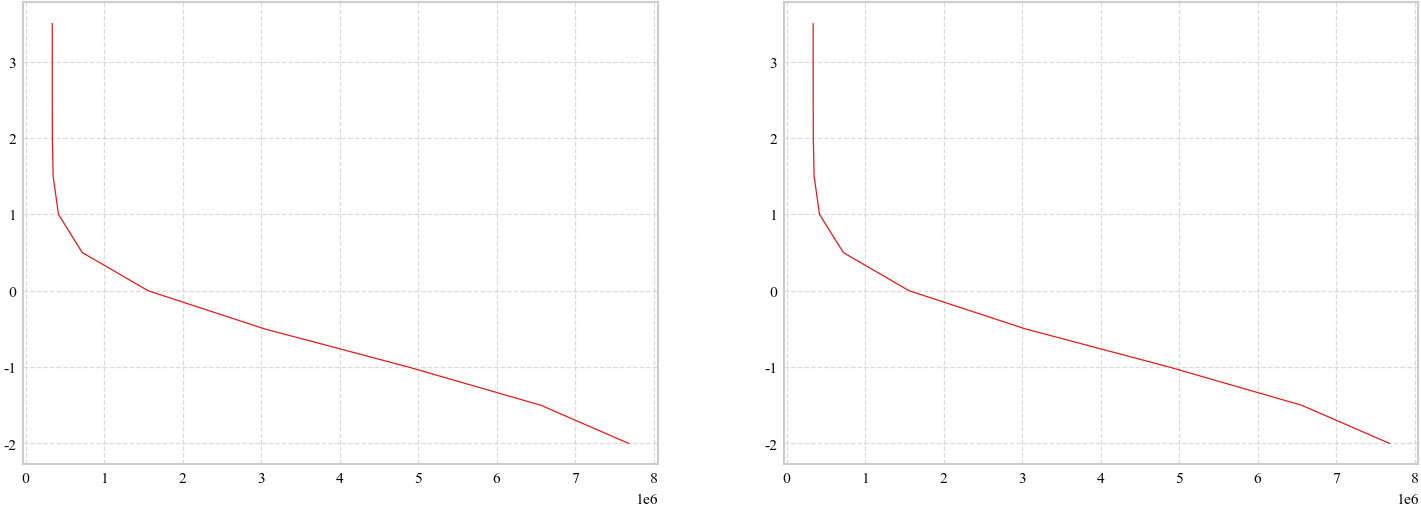

In [10]:
system.element_dim = 9

ssm = HysteresisSSM_9dof(system, time)
ssm_dm = HysteresisDMSSM5_9dof(system, time)

cov_model = np.diag([10**-6.0]*(system.dim+9)+[10**-3.0]*(system.dim))

cov_measurement = np.diag([std_noise**2]*system.dim)
cov_measurement_dm = np.diag([std_noise**2]*system.dim+[10**20.0]*system.element_dim+[10**2.5]*system.force_dim)
cov_force = [10**0]*system.force_dim

ssm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement, cov_force=cov_force)
ssm_dm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement_dm, cov_force=cov_force)

force_cov_list1 = np.arange(-2,4,.5,dtype=float)
force_cov_list2 = np.arange(-2,4,.5,dtype=float)

err = ssm.draw_Lcurve(measurement = measurement, initial_state_cov = np.eye(ssm.state_size)*10**-10.0, force_cov_list=force_cov_list1, num_cores = 16)
err_dm = ssm_dm.draw_Lcurve(measurement = measurement_dm, initial_state_cov = np.eye(ssm_dm.state_size)*10**-10.0, force_cov_list=force_cov_list2, num_cores = 16)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(err[:,0], force_cov_list1)
plt.subplot(1,2,2)
plt.plot(err_dm[:,0], force_cov_list2)
plt.show()

In [11]:
ssm = HysteresisSSM_9dof(system, time)
ssm_dm = HysteresisDMSSM5_9dof(system, time)

cov_force = [10**1.5]*system.force_dim
cov_force5 = [10**1.5]*system.force_dim

ssm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement, cov_force=cov_force)
ssm_dm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement_dm, cov_force=cov_force5)

HKFS_results = []
HKFS_ndm_results = []
time_RTS_ndm = np.zeros(m_number)
time_RTS = np.zeros(m_number)
time_HKF_ndm = np.zeros(m_number)
time_HKF = np.zeros(m_number)
for ii in range(m_number):
    measurement = measurement_set[ii]
    measurement_dm = measurement_dm_set[ii]

    start_time = time_package.perf_counter()
    response_kf, force_kf = ssm.kalmanFilter(measurement, initial_state_cov = np.eye(ssm.state_size)*10**-10)
    time_HKF_ndm[ii] = time_package.perf_counter() - start_time
    start_time = time_package.perf_counter()
    response_rts, force_rts = ssm.rtsSmoother()
    time_RTS_ndm[ii] = time_package.perf_counter() - start_time

    start_time = time_package.perf_counter()
    response_kf_dm, force_kf_dm = ssm_dm.kalmanFilter(measurement_dm, initial_state_cov = np.eye(ssm_dm.state_size)*10**-10)
    time_HKF[ii] = time_package.perf_counter() - start_time
    start_time = time_package.perf_counter()
    response_rts_dm, force_rts_dm = ssm_dm.rtsSmoother()
    time_RTS[ii] = time_package.perf_counter() - start_time
    
    HKFS_ndm_results.append((response_kf, force_kf, response_rts, force_rts))
    HKFS_results.append((response_kf_dm, force_kf_dm, response_rts_dm, force_rts_dm))
    print(f"Progress: {ii+1}/{m_number}", end='\r')

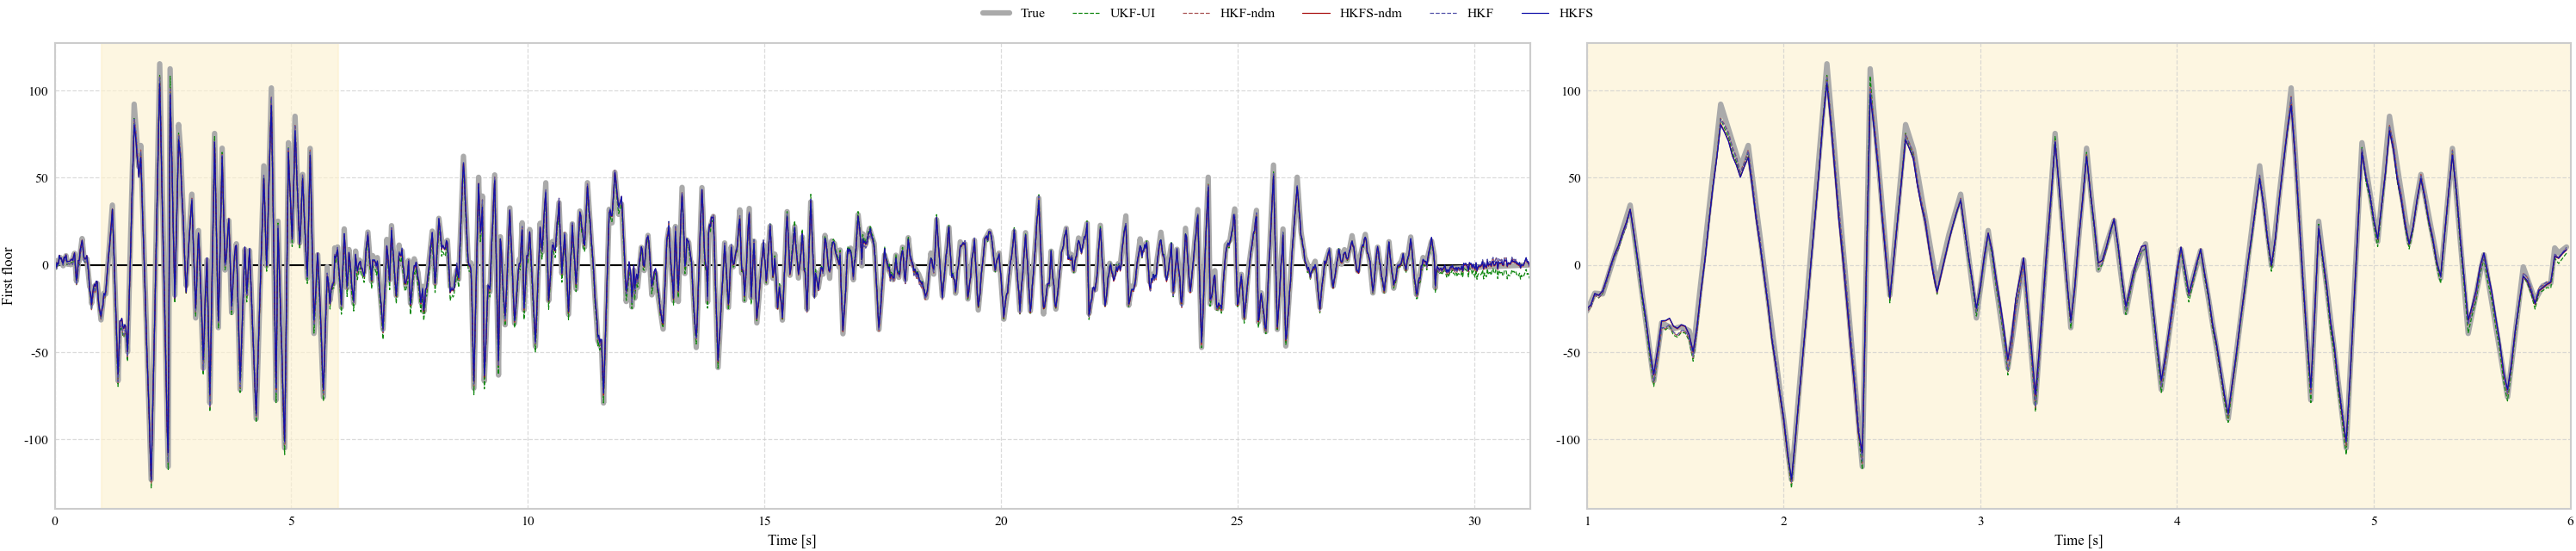

In [12]:
est_state, est_cov, est_force = UKFUI_results[0]
response_kf, force_kf, response_rts, force_rts = HKFS_ndm_results[0]
response_kf_dm, force_kf_dm, response_rts_dm, force_rts_dm = HKFS_results[0]

s = 50
e = 300
highlight_color = '#fdf2d0a0'

fig = plt.figure(figsize=(20, 4), constrained_layout=True)
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1.5,1])

axes = []
linestyles = ['--','--','-','--','-'] 
floors = ['First floor', 'Second floor', 'Third floor']

for i in range(1):
    ax_full = fig.add_subplot(gs[i, 0])
    ax_zoom = fig.add_subplot(gs[i, 1])
    axes.append((ax_full, ax_zoom))

rows = [
    dict(name="First floor",
         true_full=force.value[0],      pred_list_full=[est_force[0,:], force_kf.value[0,:], force_rts.value[0,:], force_kf_dm.value[0,:], force_rts_dm.value[0,:]],
         true_zoom=force.value[0, s:e],    pred_list_zoom=[est_force[0,s:e], force_kf.value[0,s:e], force_rts.value[0,s:e], force_kf_dm.value[0,s:e], force_rts_dm.value[0,s:e]],
         ylim_zoom=None),
]

for i, row in enumerate(rows):
    ax_full, ax_zoom = axes[i]
    
    t_start, t_end = s/50, e/50

    ax_full.axhline(0, color='k', lw=1)
    ax_full.axvspan(t_start, t_end, color=highlight_color)
    
    ax_full.plot(time.value, row["true_full"], color='#aaa', label='True', lw=3)
    for yhat, lab, col, ls in zip(row["pred_list_full"], labels, colors, linestyles):
        ax_full.plot(time.value, yhat, label=lab, color=col, ls=ls)
    ax_full.set_xlim(0, 31.18)

    ax_zoom.set_facecolor(highlight_color)
    
    ax_zoom.plot(time.value[s:e], row["true_zoom"], color='#aaa', label='True', lw=3)
    for yhat, lab, col, ls in zip(row["pred_list_zoom"], labels, colors, linestyles):
        ax_zoom.plot(time.value[s:e], yhat, color=col, ls=ls)
    ax_zoom.set_xlim(t_start, t_end)
    
    if row["ylim_zoom"] is not None:
        ax_zoom.set_ylim(*row["ylim_zoom"])

    ax_full.set_ylabel(floors[i])

axes[0][0].set_xlabel("Time [s]")
axes[0][1].set_xlabel("Time [s]")

handles, leg_labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=7, frameon=False)

fig.align_ylabels([ax[0] for ax in axes])
plt.savefig(os.path.join(fig_dir, f"estimation_excitation_{example_name}.pdf"), bbox_inches="tight")

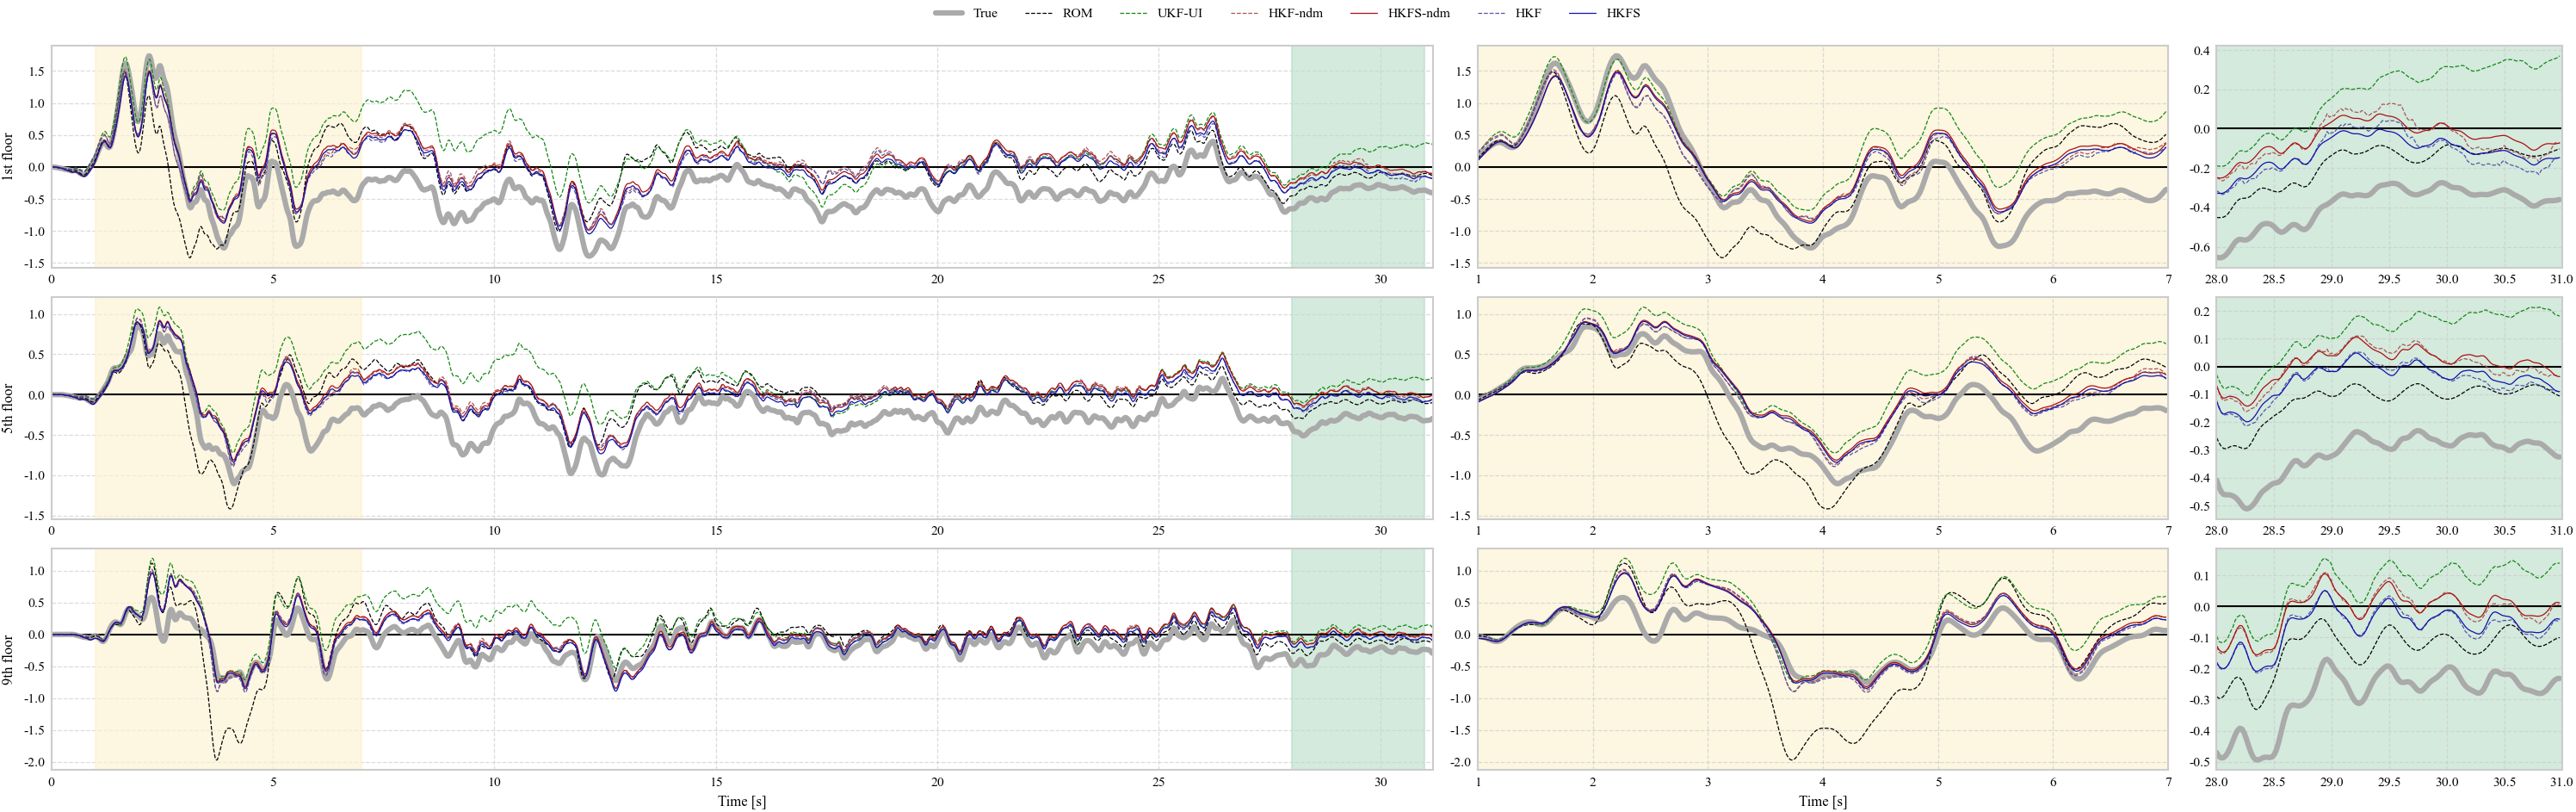

In [13]:
comp_mat = np.eye(9)
for ii in range(8):
    comp_mat[ii+1,ii] = -1

s1 = 50
e1 = 350
s2 = 1400
e2 = 1550
highlight_color1 = '#fdf2d0a0'
highlight_color2 = '#bbdecaa0'

fig = plt.figure(figsize=(20, 6), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=3, width_ratios=[2,1,0.5])

axes = []
linestyles = ['--','--','-','--','-'] 
floors = ['1st floor', '2nd floor', '3rd floor', '4th floor', '5th floor', '6th floor', '7th floor', '8th floor', '9th floor']

for i in range(3):
    ax_full = fig.add_subplot(gs[i, 0])
    ax_zoom1 = fig.add_subplot(gs[i, 1])
    ax_zoom2 = fig.add_subplot(gs[i, 2])
    axes.append((ax_full, ax_zoom1, ax_zoom2))

rows = []

for ii in [0,4,8]:
    rows.append(
        dict(name=floors[ii],
             true_full=(comp_mat@real_disp)[ii,:],
             rom_full = (comp_mat@response_rom.disp)[ii,:],
             pred_list_full=[(comp_mat@est_state[:9,:])[ii,:], (comp_mat@response_kf.disp)[ii,:], (comp_mat@response_rts.disp)[ii,:], (comp_mat@response_kf_dm.disp)[ii,:], (comp_mat@response_rts_dm.disp)[ii,:]],
             true_zoom1 = (comp_mat@real_disp)[ii,s1:e1],
             rom_zoom1 = (comp_mat@response_rom.disp)[ii,s1:e1],
             pred_list_zoom1=[(comp_mat@est_state[:9,:])[ii,s1:e1], (comp_mat@response_kf.disp)[ii,s1:e1], (comp_mat@response_rts.disp)[ii,s1:e1], (comp_mat@response_kf_dm.disp)[ii,s1:e1], (comp_mat@response_rts_dm.disp)[ii,s1:e1]],
             ylim_zoom1=None,
             true_zoom2 = (comp_mat@real_disp)[ii,s2:e2],
             rom_zoom2 = (comp_mat@response_rom.disp)[ii,s2:e2],
             pred_list_zoom2=[(comp_mat@est_state[:9,:])[ii,s2:e2], (comp_mat@response_kf.disp)[ii,s2:e2], (comp_mat@response_rts.disp)[ii,s2:e2], (comp_mat@response_kf_dm.disp)[ii,s2:e2], (comp_mat@response_rts_dm.disp)[ii,s2:e2]],
             ylim_zoom2=None)
    )


for i, row in enumerate(rows):
    ax_full, ax_zoom1, ax_zoom2 = axes[i]
    
    t_start1, t_end1 = s1/50, e1/50
    t_start2, t_end2 = s2/50, e2/50

    ax_full.axhline(0, color='k', lw=1)
    ax_full.axvspan(t_start1, t_end1, color=highlight_color1)
    ax_full.axvspan(t_start2, t_end2, color=highlight_color2)
    
    ax_full.plot(time.value, row["true_full"], color='#aaa', label='True', lw=3)
    ax_full.plot(time.value, row["rom_full"], color='k', label='ROM', ls = '--')
    for yhat, lab, col, ls in zip(row["pred_list_full"], labels, colors, linestyles):
        ax_full.plot(time.value, yhat, label=lab, color=col, ls=ls)
    ax_full.set_xlim(0, 31.18)

    ax_zoom1.set_facecolor(highlight_color1)
    ax_zoom1.axhline(0, color='k', lw=1)
    
    ax_zoom1.plot(time.value[s1:e1], row["true_zoom1"], color='#aaa', label='True', lw=3)
    ax_zoom1.plot(time.value[s1:e1], row["rom_zoom1"], color='k', label='ROM', ls = '--')
    for yhat, lab, col, ls in zip(row["pred_list_zoom1"], labels, colors, linestyles):
        ax_zoom1.plot(time.value[s1:e1], yhat, color=col, ls=ls)
    ax_zoom1.set_xlim(t_start1, t_end1)
    

    ax_zoom2.set_facecolor(highlight_color2)
    ax_zoom2.axhline(0, color='k', lw=1)
    
    ax_zoom2.plot(time.value[s2:e2], row["true_zoom2"], color='#aaa', label='True', lw=3)
    ax_zoom2.plot(time.value[s2:e2], row["rom_zoom2"], color='k', label='ROM', ls = '--')
    for yhat, lab, col, ls in zip(row["pred_list_zoom2"], labels, colors, linestyles):
        ax_zoom2.plot(time.value[s2:e2], yhat, color=col, ls=ls)
    ax_zoom2.set_xlim(t_start2, t_end2)
    
    if row["ylim_zoom1"] is not None:
        ax_zoom1.set_ylim(*row["ylim_zoom1"])
    if row["ylim_zoom2"] is not None:
        ax_zoom2.set_ylim(*row["ylim_zoom2"])

    ax_full.set_ylabel(rows[i]["name"])

axes[-1][0].set_xlabel("Time [s]")
axes[-1][1].set_xlabel("Time [s]")

handles, leg_labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=8, frameon=False)

fig.align_ylabels([ax[0] for ax in axes])
plt.savefig(os.path.join(fig_dir, f"estimation_drift_{example_name}.pdf"), bbox_inches="tight")

In [14]:
def rmse(true, pred):
    return np.sqrt(np.mean((true-pred)**2,axis=1))


rmse_force_UKFUI = np.zeros((m_number, system.force_dim))
rmse_force_HKF_ndm = np.zeros((m_number, system.force_dim))
rmse_force_HKF = np.zeros((m_number, system.force_dim))
rmse_force_HKFS_ndm = np.zeros((m_number, system.force_dim))
rmse_force_HKFS = np.zeros((m_number, system.force_dim))

rmse_drift_UKFUI = np.zeros((m_number, system.dim))
rmse_drift_HKF_ndm = np.zeros((m_number, system.dim))
rmse_drift_HKF = np.zeros((m_number, system.dim))
rmse_drift_HKFS_ndm = np.zeros((m_number, system.dim))
rmse_drift_HKFS = np.zeros((m_number, system.dim))

rmse_vel_UKFUI = np.zeros((m_number, system.dim))
rmse_vel_HKF_ndm = np.zeros((m_number, system.dim))
rmse_vel_HKF = np.zeros((m_number, system.dim))
rmse_vel_HKFS_ndm = np.zeros((m_number, system.dim))
rmse_vel_HKFS = np.zeros((m_number, system.dim))

for ii in range(m_number):
    est_state, est_cov, est_force = UKFUI_results[ii]
    response_kf, force_kf, response_rts, force_rts = HKFS_ndm_results[ii]
    response_kf_dm, force_kf_dm, response_rts_dm, force_rts_dm = HKFS_results[ii]
    
    rmse_force_UKFUI[ii,:] = rmse(force.value[:,idx_05:idx_95], est_force[:,idx_05:idx_95])
    rmse_force_HKF_ndm[ii,:] = rmse(force.value[:,idx_05:idx_95], force_kf.value[:,idx_05:idx_95])
    rmse_force_HKF[ii,:] = rmse(force.value[:,idx_05:idx_95], force_kf_dm.value[:,idx_05:idx_95])
    rmse_force_HKFS_ndm[ii,:] = rmse(force.value[:,idx_05:idx_95], force_rts.value[:,idx_05:idx_95])
    rmse_force_HKFS[ii,:] = rmse(force.value[:,idx_05:idx_95], force_rts_dm.value[:,idx_05:idx_95])
    
    rmse_drift_UKFUI[ii,:] = rmse((comp_mat@real_disp)[:,idx_05:idx_95], (comp_mat@est_state[0:system.dim])[:,idx_05:idx_95])
    rmse_drift_HKF_ndm[ii,:] = rmse((comp_mat@real_disp)[:,idx_05:idx_95], (comp_mat@response_kf.disp)[:,idx_05:idx_95])
    rmse_drift_HKF[ii,:] = rmse((comp_mat@real_disp)[:,idx_05:idx_95], (comp_mat@response_kf_dm.disp)[:,idx_05:idx_95])
    rmse_drift_HKFS_ndm[ii,:] = rmse((comp_mat@real_disp)[:,idx_05:idx_95], (comp_mat@response_rts.disp)[:,idx_05:idx_95])
    rmse_drift_HKFS[ii,:] = rmse((comp_mat@real_disp)[:,idx_05:idx_95], (comp_mat@response_rts_dm.disp)[:,idx_05:idx_95])



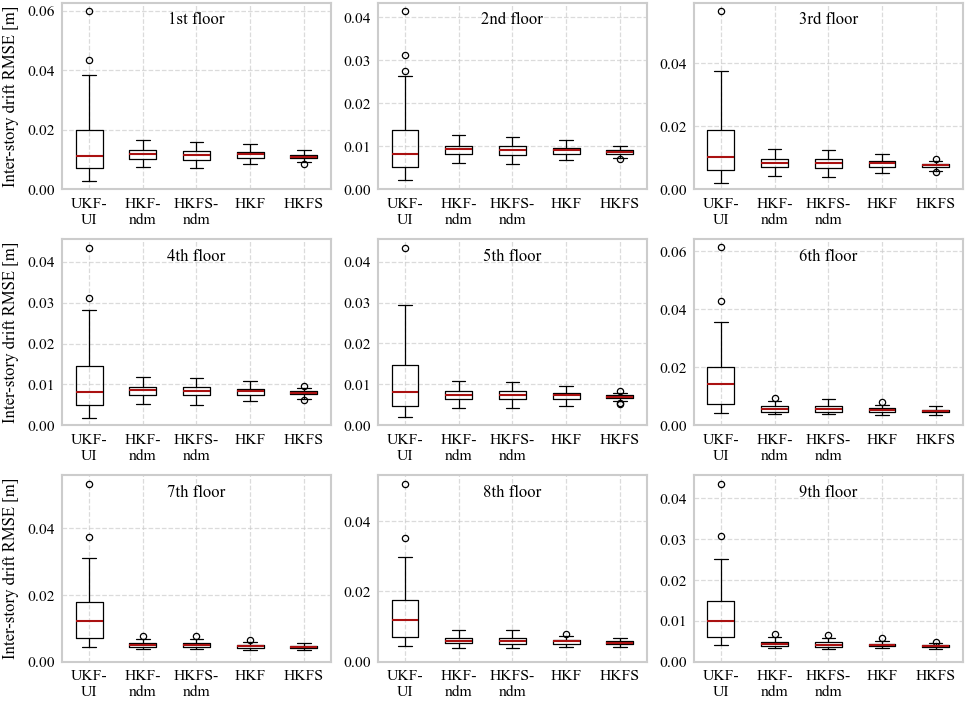

In [15]:
axes_row = []

labels = ['UKF-\nUI','HKF-\nndm','HKFS-\nndm','HKF','HKFS',]
fig = plt.figure(figsize=(FIG_W, FIG_H*3*1.6), constrained_layout=True)
for f in range(system.dim):
    ax = plt.subplot(3,3,f+1)
    bp = ax.boxplot([rmse_drift_UKFUI[:,f]*0.0254, rmse_drift_HKF_ndm[:,f]*0.0254, rmse_drift_HKFS_ndm[:,f]*0.0254, rmse_drift_HKF[:,f]*0.0254, rmse_drift_HKFS[:,f]*0.0254], labels=labels, medianprops=dict(color=colors[2]))
    axes_row.append(ax)
    for b in bp["boxes"]:
        b.set_linewidth(0.6)
    for w in bp["whiskers"]:
        w.set_linewidth(0.6)
    for c in bp["caps"]:
        c.set_linewidth(0.6)
    for fl in bp["fliers"]:
        fl.set_markeredgewidth(0.6)
        fl.set_markersize(3)
    ax.text(0.5, 0.95, floors[f], transform=ax.transAxes, ha="center", va="top")
    if f in [0,3,6]:
        plt.ylabel('Inter-story drift RMSE [m]')
    plt.ylim(bottom=0)
fig.align_ylabels(axes_row)
plt.savefig(os.path.join(fig_dir, f"rmse_disp_{example_name}.pdf"), bbox_inches="tight")



In [16]:
print(f"Average time UKFUI: {np.mean(time_UKF):.4g}")
print(f"Average time HKF NDM: {np.mean(time_HKF_ndm):.4g}")
print(f"Average time HKFS NDM: {np.mean(time_HKF_ndm + time_RTS_ndm):.4g}")
print(f"Average time HKF: {np.mean(time_HKF):.4g}")
print(f"Average time HKFS: {np.mean(time_HKF + time_RTS):.4g}")

Average time UKFUI: 4.84
Average time HKF NDM: 0.2617
Average time HKFS NDM: 0.3302
Average time HKF: 0.2747
Average time HKFS: 0.3424


In [17]:
import pickle

results_data = {
    'UKFUI_results': UKFUI_results,
    'HKFS_ndm_results': HKFS_ndm_results,
    'HKFS_results': HKFS_results,
    'time_UKF': time_UKF,
    'time_HKF_ndm': time_HKF_ndm,
    'time_HKF': time_HKF,
    'time_RTS_ndm': time_RTS_ndm,
    'time_RTS': time_RTS,
    'rmse_force_UKFUI': rmse_force_UKFUI,
    'rmse_force_HKF_ndm': rmse_force_HKF_ndm,
    'rmse_force_HKF': rmse_force_HKF,
    'rmse_force_HKFS_ndm': rmse_force_HKFS_ndm,
    'rmse_force_HKFS': rmse_force_HKFS,
    'rmse_drift_UKFUI': rmse_drift_UKFUI,
    'rmse_drift_HKF_ndm': rmse_drift_HKF_ndm,
    'rmse_drift_HKF': rmse_drift_HKF,
    'rmse_drift_HKFS_ndm': rmse_drift_HKFS_ndm,
    'rmse_drift_HKFS': rmse_drift_HKFS
}

save_path = os.path.join(data_dir, f'results_{example_name}.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(results_data, f)
